In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint

# Constants
M_sun = 2e33
M_tot = 0.01 * M_sun
c = 3e10
v_min = 0.1 * c
beta = 3
numshells = 10
sigma = 5.67e-5
h = 6.626e-27
nu = 1e14
D = 1e26
kB = 1.38e-16

# Time array
t = np.logspace(0, 6, 50)

# Opacity parameters
av, bv, cv = 0.56, 0.71, 0.74
xr = 0.6
kv = [20, 5, 1]

def eps_th_v(t):
    t_day = t / 86400
    return 0.36 * (np.exp(-av * t_day) + np.log(1 + 2 * bv * t_day**cv) / (2 * bv * t_day**cv))

def e_dot_r(t):
    t0, sigma_val = 1.3, 0.11
    return 4e18 * eps_th_v(t) * (0.5 - (1 / np.pi) * np.arctan((t - t0) / sigma_val))**1.3

def Q_rv(Mv, t):
    return Mv * xr * e_dot_r(t)

def t_diff(M_shells, t):
    return ((M_shells**(4./3.)) * kv[1]) / (4 * np.pi * (M_tot**(1./3.)) * v_min * t * c)

def L_v(R, Eint, t_diff):
    return Eint / (t_diff + (R / c))

def energy(y, t, M):
    Eint, R, v = y
    if R < 1e8:
        R = 1e8
    diff_time = t_diff(M, t)
    dEint = -((Eint / R) * v) + Q_rv(M, t) - L_v(R, Eint, diff_time)
    dR = v
    dv = Eint / (M * R)
    return [dEint, dR, dv]

def pre_solve_shells(shell_data, t):
    E_all, R_all, v_all = [], [], []
    for i, row in shell_data.iterrows():
        M = row['Mass (g)']
        Eint0 = row['Internal Energy (erg)']
        v0 = row['Velocity (cm/s)']
        y0 = [Eint0, 1e9, v0]
        Edep = odeint(energy, y0, t, args=(M,))
        if not np.all(np.isfinite(Edep)):
            raise ValueError(f"ODE failed at shell {i}")
        E_all.append(Edep[:, 0])
        R_all.append(Edep[:, 1])
        v_all.append(Edep[:, 2])
    return np.array(E_all), np.array(R_all), np.array(v_all)

def compute_photosphere_radius(R_all, shell_masses, t):
    num_shells, num_times = R_all.shape
    R_ph = np.zeros(num_times)
    tau_all = kv[2] * shell_masses[:, None] / (4 * np.pi * R_all**2)
    tau_cumu = np.cumsum(tau_all[::-1], axis=0)[::-1]
    for i in range(num_times):
        tau_t = tau_cumu[:, i]
        if tau_t[-1] < 1:
            R_ph[i] = R_all[-1, i]
        else:
            idx = np.argmax(tau_t >= 1)
            if idx == 0:
                R_ph[i] = R_all[0, i]
            else:
                tau_low, tau_high = tau_t[idx-1], tau_t[idx]
                R_low, R_high = R_all[idx-1, i], R_all[idx, i]
                f = (1 - tau_low) / (tau_high - tau_low)
                R_ph[i] = R_low + f * (R_high - R_low)
    return R_ph

def calculate_flux(R_ph, L_tot):
    T_eff = (L_tot / (4 * np.pi * sigma * R_ph**2))**0.25
    exponent = np.clip((h * nu) / (kB * T_eff), 1e-3, 700)
    planck_term = 1 / np.expm1(exponent)
    return ((2 * np.pi * h * nu**3) / c**2) * planck_term * (R_ph**2 / D**2)


100%|██████████| 10000/10000 [16:59:45<00:00,  6.12s/it] 


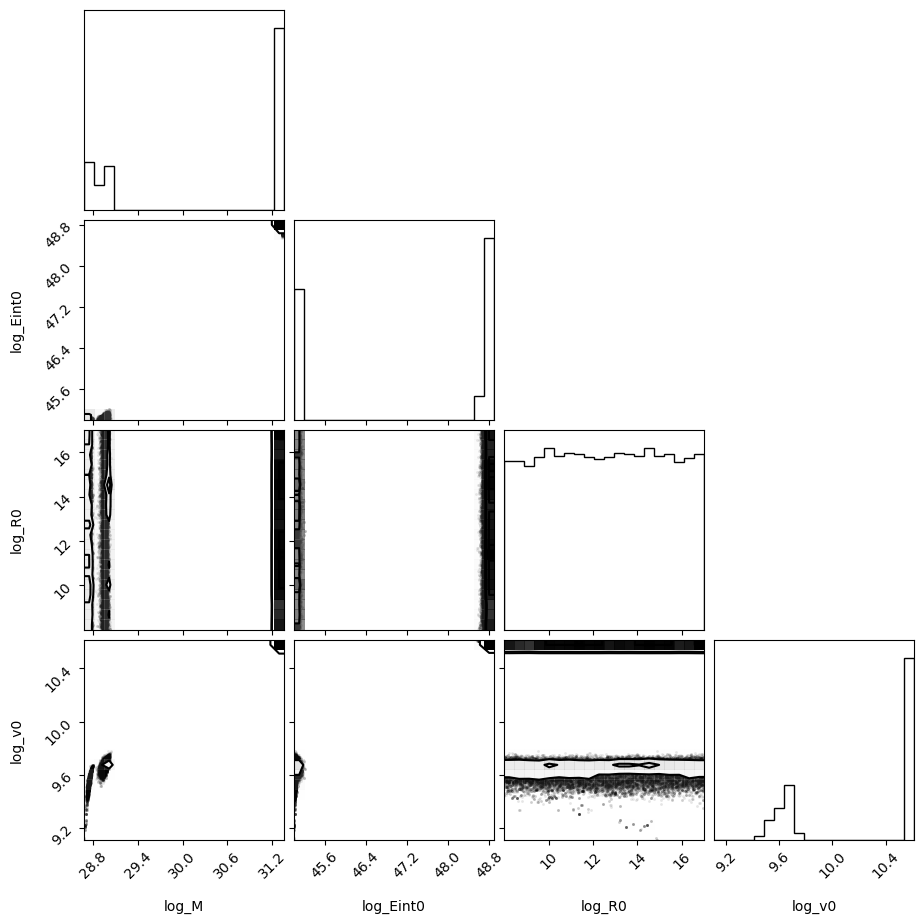

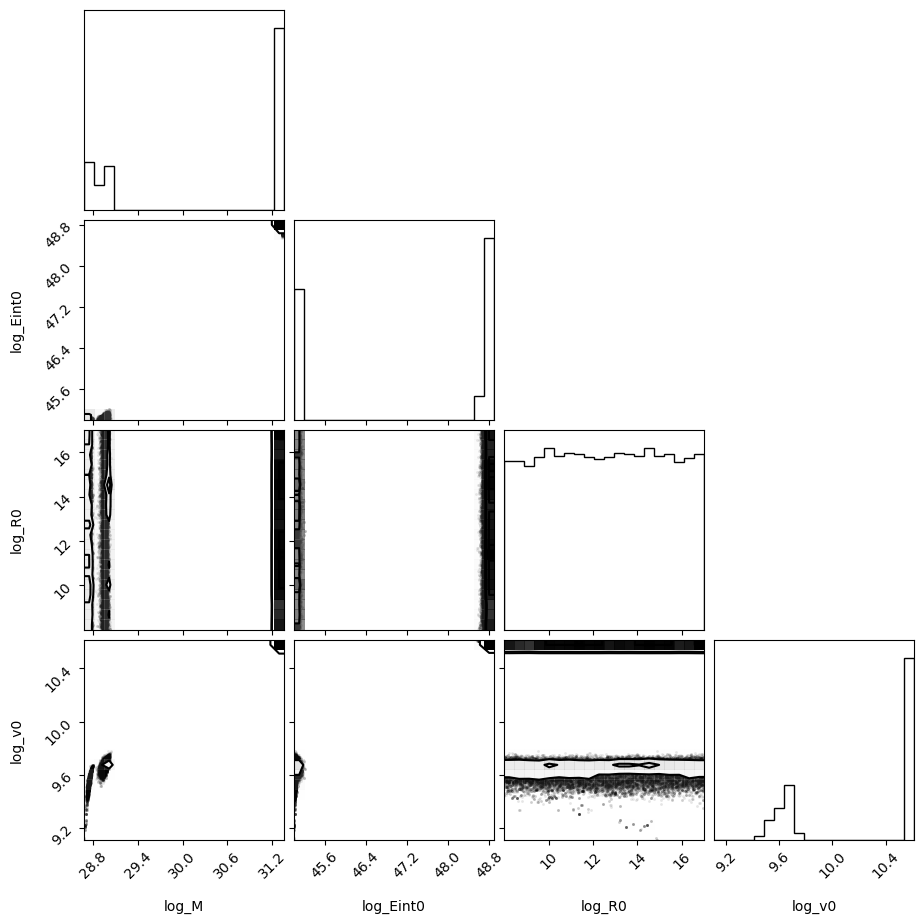

In [3]:
import emcee
import corner

# Reuse t from presolve block
# Load initial values from presolve setup
v_shells = np.linspace(0.1, 1, numshells) * c
M_shells = beta * M_tot * (v_min**beta) * (v_shells**(-beta - 1))
M_shells = M_shells * M_tot / np.sum(M_shells)
E_int_shells = 0.5 * M_shells * (v_shells**2)
E_all, R_all, _ = pre_solve_shells(pd.DataFrame({
    'Velocity (cm/s)': v_shells,
    'Mass (g)': M_shells,
    'Internal Energy (erg)': E_int_shells
}), t)

R_ph = compute_photosphere_radius(R_all, M_shells, t)

L_tot = np.sum([
    L_v(R_all[i], E_all[i], t_diff(M_shells[i], t))
    for i in range(numshells)
], axis=0)

Flux_true = calculate_flux(R_ph, L_tot)

noise = 0.1 * Flux_true
Flux_perturbed = Flux_true + noise * np.random.randn(*Flux_true.shape)

def model(theta, t):
    log_M_tot, log_Eint0, log_R0, log_v0 = theta
    try:
        M_tot = 10**log_M_tot
        Eint0 = 10**log_Eint0
        R0 = 10**log_R0
        v0 = 10**log_v0

        v_shells = np.linspace(0.1, 1, numshells) * v0
        M_shells = beta * M_tot * (v_min**beta) * (v_shells**(-beta - 1))
        M_shells = M_shells * M_tot / np.sum(M_shells)
        E_int_shells = np.full_like(v_shells, Eint0 / numshells)

        shell_data = pd.DataFrame({
            'Velocity (cm/s)': v_shells,
            'Mass (g)': M_shells,
            'Internal Energy (erg)': E_int_shells
        })

        E_all, R_all, v_all = pre_solve_shells(shell_data, t)
        R_ph = compute_photosphere_radius(R_all, M_shells, t)
        L_tot = np.sum([
            L_v(R, E, t_diff(M_shells[i], t))
            for i, (R, E) in enumerate(zip(R_all, E_all))
        ], axis=0)
        flux = calculate_flux(R_ph, L_tot)
        if not np.all(np.isfinite(flux)):
            return np.full_like(t, -np.inf)
        return flux
    except Exception:
        return np.full_like(t, -np.inf)

def log_prior(theta):
    log_M_tot, log_Eint0, log_R0, log_v0 = theta
    if (27 < log_M_tot < 34 and 45 < log_Eint0 < 51 and 8 < log_R0 < 17 and 8 < log_v0 < 11):
        return 0.0
    return -np.inf

def log_likelihood(theta, t, y, yerr):
    model_flux = model(theta, t)
    if np.any(np.isinf(model_flux)):
        return -np.inf
    return -0.5 * np.sum(((y - model_flux) / yerr)**2)

def log_posterior(theta, t, y, yerr):
    lp = log_prior(theta)
    return lp + log_likelihood(theta, t, y, yerr) if np.isfinite(lp) else -np.inf

def run_mcmc(initial, t, y, yerr, nsteps=10000, nwalkers=100, ndim=4):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t, y, yerr))
    sampler.run_mcmc(initial, nsteps, progress=True)
    return sampler

# Initialize walkers around known values
log_M_tot = np.log10(np.sum(M_shells))
log_Eint0 = np.log10(np.sum(E_int_shells))
log_R0 = np.log10(1e9)
log_v0 = np.log10(np.mean(v_shells))

ndim, nwalkers = 4, 100
initial = np.array([log_M_tot, log_Eint0, log_R0, log_v0]) + \
          np.random.randn(nwalkers, ndim) * [0.1, 0.1, 0.1, 0.05]

sampler = run_mcmc(initial, t, Flux_perturbed, noise)
samples = sampler.get_chain(discard=1000, thin=10, flat=True)
corner.corner(samples, labels=["log_M", "log_Eint0", "log_R0", "log_v0"])
